# Exploració de dades RNA-seq del TCGA-COAD
## Preprocessament pas a pas: observació, problema, decisió i efecte

---

**Projecte:** Pipeline de ML per classificar subtipus moleculars (CMS) de càncer colorectal  
**Dades:** TCGA-COAD · 483 pacients · ~60.000 gens · RNA-seq (STAR-Counts)  
**Públic objectiu:** Informàtics sense coneixements previs de bioinformàtica

---

### Sobre aquest document

Aquest notebook és un **document tècnic explicatiu**: no és un entorn de proves ni una col·lecció de gràfics. El seu objectiu és documentar, justificar i visualitzar cada decisió del procés de preparació de les dades.

Per a cada pas del pipeline, seguirem sempre la mateixa lògica:

| Pas | Pregunta que respon |
|:---:|---------------------|
| 🔍 **Observació** | Què veiem a les dades en l'estat actual? |
| ⚠️ **Problema** | Per què l'estat actual és una limitació? |
| 🎯 **Decisió** | Quina transformació o filtre apliquem? |
| 📐 **Criteri** | Amb quin llindar o raonament exacte? |
| 💻 **Codi** | Com s'implementa? |
| 📊 **Resultat** | Quin aspecte tenen les dades ara? |
| ✅ **Validació** | La transformació ha complert l'objectiu? |

Al final d'aquest procés, les **296 mostres × 15.625 gens** resultants entren als models de classificació de l'Etapa 4.

---
## 1. Context: Dades RNA-seq per a informàtics

### Què és RNA-seq i com es generen les dades

**RNA-seq** (*RNA sequencing*) és una tècnica experimental que mesura el nivell d'activitat de cada gen en una mostra de teixit. Penseu-hi com si fos una foto instantània de quins gens estan «encesos» i quant.

El resultat és una taula de nombres enters:

```
               Pacient_A  Pacient_B  Pacient_C  ...
ENSG00000001       12        345         0
ENSG00000002     1203       8901      2340
ENSG00000003        0          0         1
ENSG00060664     4521        123       980
```

- **Cada fila** és un gen (identificat per un codi ENSEMBL: `ENSG...`)
- **Cada columna** és un pacient (una mostra de teixit tumoral)
- **Cada valor** és un *comptatge* (*read count*): quantes vegades la seqüenciació ha detectat aquell gen en aquella mostra

Cada columna és el «perfil molecular» d'un pacient: ~60.000 nombres que descriuen l'estat bioquímic del seu tumor.

### Fitxers originals: 483 fitxers TSV, un per pacient

Cada fitxer el genera l'eina **STAR** i conté 9 columnes:

| Columna | Descripció |
|---------|------------|
| `gene_id` | Identificador ENSEMBL (`ENSG...`) |
| `gene_name` | Nom llegible (`TP53`, `BRCA1`, etc.) |
| `gene_type` | Tipus biológic (`protein_coding`, `lncRNA`, ...) |
| **`unstranded`** | Comptatge total sense distinció de cadena — **la columna que usem** |
| `tpm_unstranded` | TPM (ja normalitzat per longitud i profunditat de seqüenciació) |
| `fpkm_unstranded` | FPKM (ja normalitzat) |
| ... | Altres columnes normalitzades |

**Per què `unstranded` i no TPM/FPKM?**  
TPM i FPKM ja han estat normalitzats externament. Sembla convenient, però ens priva del control sobre el procés de normalització. Preferim partir de **comptatges raw** i aplicar les nostres pròpies transformacions: és la base d'un pipeline reproduïble i auditable.

### Subtipus moleculars CMS: el problema de classificació

**CMS** (*Consensus Molecular Subtypes*) és una classificació del càncer colorectal en **4 subtipus moleculars** publicada per Guinney et al. (2015, *Nature Medicine*). Cada subtipus té un patró d'expressió gènica característic:

| Subtipus | Nom popular | Característica molecular principal |
|----------|-------------|------------------------------------|
| **CMS1** | MSI Immune | Hipermutació, alta activitat immunitària |
| **CMS2** | Canonical | Activació de les vies WNT i MYC |
| **CMS3** | Metabolic | Desregulació metabòlica; subtipus «mixt» |
| **CMS4** | Mesenchymal | Activació TGF-β; pitjor pronòstic |

### El problema de ML

Donada l'expressió gènica d'una mostra nova (un vector de 15.625 valors numèrics), volem predir a quin subtipus CMS pertany:

```
Entrada:  [gen_1=2.3,  gen_2=11.7,  gen_3=0.0,  ...,  gen_15625=8.4]
                    ↓
             Model (LR / RF / SVM)
                    ↓
Sortida:  CMS2   (prob: CMS1=0.05, CMS2=0.78, CMS3=0.08, CMS4=0.09)
```

És un problema de **classificació multiclasse** (4 classes). L'objectiu d'aquest TFG no és trobar el model perfecte, sinó **comparar tres algoritmes** en condicions idèntiques.

### El pipeline de preprocessament: de dades brutes a ML-ready

Abans d'entrenar cap model, les dades passen per 7 transformacions seqüencials. El diagrama mostra l'ordre i les dimensions resultants en cada etapa:

```
483 fitxers raw  (60.664 gens × 483 pacients)
        │
        ▼
  [Pas 1] Eliminar 4 files QC (N_unmapped, etc.)         → 60.660 gens
        │
        ▼
  [Pas 2] Filtrar gens no protein-coding (GENCODE v36)   → 19.962 gens
        │
        ▼
  [Pas 3] Deduplicar mostres (FFPE + duplicats)          → 458 mostres
        │
        ▼
  [Pas 4] Inner join amb etiquetes CMS                    → 370 mostres
        │
        ▼
  [Pas 5] Split estratificat train/test 80/20             → 296 train + 74 test
  ════════════════════════════════════════════════════════════════════
  A partir d'aquí: tot es calcula sobre TRAIN → s'aplica a TRAIN+TEST
  ════════════════════════════════════════════════════════════════════
        │
        ▼
  [Pas 6] Filtrar gens de baixa expressió                → 15.625 gens
        │
        ▼
  [Pas 7] Transformació log₂(x+1)                        → rang [0.00, 20.71]
        │
        ▼
  DATASET FINAL: X_train (296 × 15.625) + X_test (74 × 15.625)
```

**Dos blocs separats pel split:**

- **Bloc 1 — Passos 1–4:** Decisions basades en *metadades* (quin tipus de gen, quin tipus de mostra, si hi ha etiqueta CMS). No miren els valors d'expressió → no generen *data leakage* i es poden aplicar a tot el dataset.
- **Bloc 2 — Passos 6–7:** Decisions basades en els *valors d'expressió*. S'han de calcular exclusivament sobre el conjunt d'entrenament per evitar que el test contamini les decisions de normalització.

In [2]:
# ── Imports ────────────────────────────────────────────────────────────────────
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src.gdc_utils import repo_root
from src.dimensionality_reduction import (
    fit_pca, apply_pca,
    plot_explained_variance,
    plot_top_genes, plot_umap_scatter,
)

warnings.filterwarnings('ignore', category=FutureWarning)

# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT      = repo_root()
PROCESSED = ROOT / 'data' / 'processed'
FIGURES   = ROOT / 'figures'
FIGURES.mkdir(exist_ok=True)

# ── Paleta de colors consistent per als subtipus CMS ──────────────────────────
CMS_PALETTE = {'CMS1': '#E41A1C', 'CMS2': '#377EB8', 'CMS3': '#4DAF4A', 'CMS4': '#FF7F00'}
CMS_ORDER   = ['CMS1', 'CMS2', 'CMS3', 'CMS4']

# ── Estil global ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        120,
    'font.size':          11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

# Generador aleatori amb seed fixa (per a UMAP i submostreigs de gens)
rng = np.random.default_rng(42)

print('✓ Setup completat.')
print(f'  Dades processades : {PROCESSED}')
print(f'  Figures           : {FIGURES}')

✓ Setup completat.
  Dades processades : /home/mrivero/tcga-coad-cms-ml-pipeline/data/processed
  Figures           : /home/mrivero/tcga-coad-cms-ml-pipeline/figures


---
## 2. Visió global del preprocessament

### Càrrega del registre del pipeline

Cada vegada que s'executa `scripts/preprocess.py`, es genera automàticament el fitxer `preprocessing_log.json` que registra tots els comptadors, paràmetres i timestamps del procés. Llegir-lo ens dóna una vista panoràmica de tot el que ha passat sense necessitat de tornar a executar el pipeline.

In [5]:
with open(PROCESSED / 'preprocessing_log.json') as f:
    log = json.load(f)

# Valors del log (amb fallback per compatibilitat amb versions anteriors)
n_pc    = log.get('genes_after_protein_coding', 19962)
n_filt  = log.get('genes_after_low_count_filter', 15625)
n_dedup = log.get('samples_after_dedup', 458)
n_cms   = log.get('samples_with_cms_labels', 370)
n_tr    = log.get('train_samples', 296)
n_te    = log.get('test_samples', 74)

steps = pd.DataFrame([
    {'#': '1', 'Pas': 'Fitxers RNA-seq bruts',                  'Mostres': '483',                              'Gens': '60.664',     'Canvi': '—'},
    {'#': '2', 'Pas': 'Eliminar files QC de STAR',              'Mostres': '483',                              'Gens': '60.660',     'Canvi': '−4 files'},
    {'#': '3', 'Pas': 'Filtrar gens protein-coding (GENCODE)',  'Mostres': '483',                              'Gens': f'{n_pc:,}',  'Canvi': '−40.698 gens'},
    {'#': '4', 'Pas': 'Deduplicar mostres (FFPE + duplicats)',  'Mostres': f'{n_dedup}',                       'Gens': f'{n_pc:,}',  'Canvi': '−25 mostres'},
    {'#': '5', 'Pas': 'Inner join etiquetes CMS (Synapse)',     'Mostres': f'{n_cms}',                         'Gens': f'{n_pc:,}',  'Canvi': '−88 mostres'},
    {'#': '6', 'Pas': 'Split estratificat train/test (80/20)',  'Mostres': f'{n_tr} train + {n_te} test',      'Gens': f'{n_pc:,}',  'Canvi': '—'},
    {'#': '7', 'Pas': 'Filtrar gens baixa expressió',           'Mostres': f'{n_tr} train + {n_te} test',      'Gens': f'{n_filt:,}','Canvi': f'−{n_pc - n_filt:,} gens'},
    {'#': '8', 'Pas': 'Transformació log₂(x+1)  — FINAL',   'Mostres': f'{n_tr} train + {n_te} test',      'Gens': f'{n_filt:,}','Canvi': 'rang [0, ~21]'},
])

display(
    steps.style
    .hide(axis='index')
    .set_caption('Evolució de les dades al llarg del pipeline de preprocessament')
    .set_properties(**{'text-align': 'left', 'padding': '5px 14px'})
)

print(f'\nParàmetres del pipeline:')
print(f'  Seed aleatòria          : {log.get("random_seed", 42)}')
print(f'  Fracció del test set    : {log.get("test_size", 0.2)*100:.0f}%')
print(f'  Llindar comptatge mínim : {log.get("min_count_threshold", 10)} lectures')
print(f'  Fracció mínima de mostres: {log.get("min_sample_fraction", 0.2)*100:.0f}%')

#,Pas,Mostres,Gens,Canvi
1,Fitxers RNA-seq bruts,483,60.664,—
2,Eliminar files QC de STAR,483,60.660,−4 files
3,Filtrar gens protein-coding (GENCODE),483,"19,962",−40.698 gens
4,Deduplicar mostres (FFPE + duplicats),370,"19,962",−25 mostres
5,Inner join etiquetes CMS (Synapse),370,"19,962",−88 mostres
6,Split estratificat train/test (80/20),296 train + 74 test,"19,962",—
7,Filtrar gens baixa expressió,296 train + 74 test,"15,625","−4,337 gens"
8,Transformació log₂(x+1) — FINAL,296 train + 74 test,"15,625","rang [0, ~21]"



Paràmetres del pipeline:
  Seed aleatòria          : 42
  Fracció del test set    : 20%
  Llindar comptatge mínim : 10 lectures
  Fracció mínima de mostres: 20%


**Interpretació de la taula:**

- Les dades passen de **60.664 → 15.625 gens** (−74%) gràcies a tres filtratges successius: eliminació de metadades d'alineació, restricció a gens protein-coding, i eliminació de gens poc expressats.
- Les mostres passen de **483 → 370** (−23%) principalment perquè molts pacients TCGA no van ser inclosos a l'estudi de Guinney (2015) o no tenien etiqueta CMS vàlida.
- La **frontera del split (pas 6)** és crítica: tot el que ve a continuació s'ha de calcular sobre train i aplicar al test.

---
## 3. Pas 1: Eliminació de les files QC de STAR

### 🔍 Observació

Cada fitxer STAR-Counts comença amb **4 files especials** que no corresponen a gens reals sinó a estadístiques internes d'alineació:

| Fila | Significat |
|------|------------|
| `N_unmapped` | Lectures que **no** s'han pogut alinear al genoma de referència |
| `N_multimapping` | Lectures que alineen a **múltiples ubicacions** (ambigüitat) |
| `N_noFeature` | Lectures alineades però que cauen **fora de qualsevol gen** |
| `N_ambiguous` | Lectures que cauen en **zones de solapament** entre dos gens |

### ⚠️ Problema

Si no s'eliminessin, un algorisme de ML les tractaria com si fossin gens normals. El model podria aprendre, per exemple, que «els pacients CMS2 solen tenir un valor `N_unmapped` alt» — però això seria un artefacte de la qualitat tècnica de la seqüenciació, no informació biológica real sobre el subtipus CMS.

### 🎯 Decisió i resultat

Eliminar les 4 files identificades pel prefix `N_`. Resultat: **60.664 → 60.660 gens**.

> En aquest notebook no podem mostrar l'estat «antes» d'aquest pas perquè `X_train.csv` ja ha estat processat. El registre `preprocessing_log.json` confirma que s'han eliminat.

---
## 4. Pas 2: Filtratge de gens no protein-coding

### 🔍 Observació

L'anotació **GENCODE v36** classifica cada gen per tipus biológic. Dels ~60.660 gens que tenim:

| Tipus de gen | Funció biológica | Nombre aprox. |
|--------------|-----------------|:--------------:|
| `protein_coding` | Codifiquen proteïnes funcionals | ~19.962 |
| `lncRNA` | RNA llarg no codificant (regulació genètica) | ~16.000 |
| `pseudogene` | Còpies de gens que ja no es tradueixen | ~15.000 |
| Altres | miRNA, rRNA, snRNA... | ~9.000 |
| **Total** | — | **~60.660** |

### ⚠️ Problema

La classificació CMS es basa en **signatures d'expressió de proteïnes** funcionals. Els gens no codificants:

1. **Afegeixen dimensionalitat innecessària**: passar de ~60.000 a ~20.000 dimensions redueix el risc de sobreajustament.
2. **La seva relació amb els subtipus CMS és poc establerta**: el paper original de Guinney et al. (2015) utilitza gens protein-coding.
3. **Introdueixen soroll sense senyal discriminativa clara** per al problema de classificació CMS.

### 🎯 Decisió i criteri

Conservar **únicament** els gens de tipus `protein_coding` segons GENCODE v36.  
Resultat: **60.660 → 19.962 gens** (s'eliminen ~40.698 gens no codificants, −67%).

> Aquesta decisió **no genera data leakage** perquè es basa en l'anotació externa GENCODE, no en els valors d'expressió del dataset.

---
## 5. Pas 3: Deduplicació de mostres

### 🔍 Observació

Els 483 fitxers no corresponen a 483 pacients únics. Hi ha **tres categories** de casos problemàtics:

### ⚠️ Problema A — Mostres FFPE (13 eliminades)

**FFPE** (*Formalin-Fixed Paraffin-Embedded*) és una tècnica de conservació de teixit amb formaldehid. Comparades amb teixit congelat (l'estàndard per a RNA-seq), les mostres FFPE pateixen degradació del RNA i biaixos sistemàtics en els comptatges.

Barrejar mostres FFPE amb mostres congelades introduiria **variabilitat tècnica** (artefacte del processament de la mostra) que el model podria confondre amb **variabilitat biológica** (subtipus CMS).

### ⚠️ Problema B — Mostres no primàries (2 eliminades)

Els codis TCGA identifiquen el tipus de teixit. Tenim una mostra **metastàtica** (`06A`) i una de **recurrència** (`02A`). L'objectiu és classificar **tumors primaris** (`01A`); metàstasis i recurrències poden tenir perfils d'expressió alterats.

### ⚠️ Problema C — Pacients duplicats (10 eliminats)

Deu pacients (`A6-*`) apareixen dos cops. Per a cada parella, es conserva el fitxer amb **major profunditat de seqüenciació** (suma total de comptatges), perquè conté més informació.

### 🎯 Resultat

S'eliminen 13 + 2 + 10 = **25 fitxers**. Resultat: **483 → 458 mostres**, 1 fitxer per pacient.

---
## 6. Pas 4: Adjunció d'etiquetes CMS

### 🔍 Observació

Les dades TCGA **no inclouen les etiquetes CMS**. Els subtipus van ser definits per Guinney et al. (2015) en un estudi independent que va classificar una selecció de pacients TCGA-COAD — però no tots. Les etiquetes estan disponibles a Synapse (`syn4978511`).

### ⚠️ Problema

L'aprenentatge **supervisat** requereix que cada mostra d'entrenament tingui una etiqueta coneguda. Sense etiqueta, no podem dir al model «aquesta mostra és CMS2». Alguns pacients, a més, van rebre etiqueta `NOLBL` o `UNK` (no classificables).

### 🎯 Decisió i resultat

Fer un **inner join** entre la matriu d'expressió i el fitxer d'etiquetes, conservant únicament les mostres amb etiqueta vàlida (`CMS1`, `CMS2`, `CMS3` o `CMS4`).

Resultat: **458 → 370 mostres** (es descarten 88 pacients sense etiqueta vàlida, −19%).

| Subtipus | Mostres | % |
|----------|:-------:|:---:|
| CMS2 | 145 | 39% |
| CMS4 | 100 | 27% |
| CMS1 | 71 | 19% |
| CMS3 | 54 | 15% |

> El desbalanceig (CMS2=39% vs CMS3=15%) és **biológicament real**, no un artefacte del mostreig.

---
## 7. Pas 5: Divisió train/test estratificada

### 🔍 Observació i decisió

Tenim 370 mostres etiquetades. Cal dividir-les en:
- **Conjunt d'entrenament (*train*)**: les mostres que el model veu durant l'aprenentatge.
- **Conjunt de test**: les mostres que el model **mai ha vist** i que usem per avaluar el rendiment real.

### Per què dividim aquí, *abans* de normalitzar?

Aquesta és la decisió clau per evitar ***data leakage*** (fuga d'informació del test cap a l'entrenament):

> **Data leakage**: si un pas de preparació usa informació del test per prendre decisions (per exemple, calcular la mitjana de tot el dataset per normalitzar), el model «veu» indirectament les dades de test durant l'entrenament. Les mètriques d'avaluació resultants seran massa optimistes i no reflectiran el rendiment real sobre dades noves.

Els passos 6 i 7 (filtratge de gens i normalització) depenen dels valors d'expressió. Hem d'assegurar que els paràmetres es calculin **exclusivament** sobre les dades d'entrenament:

```
❌ MAL:  params = calcula(train + test)   ← test influeix en els paràmetres
✓  BÉ:  params = calcula(train)           ← test no intervé en el càlcul
         aplica(train, params)
         aplica(test,  params)            ← test hereta, no defineix
```

### Per què estratificat?

Amb un split aleatori simple, CMS3 (54 mostres) podria quedar molt poc representada al test. Un split **estratificat** garanteix que les proporcions de cada subtipus es mantenen en ambdós conjunts. Resultat: **296 train + 74 test** (seed = 42 per a reproducibilitat).

In [6]:
# ── Càrrega de les dades processades ──────────────────────────────────────────
X_train    = pd.read_csv(PROCESSED / 'X_train.csv', index_col=0)
X_test     = pd.read_csv(PROCESSED / 'X_test.csv',  index_col=0)
y_train    = pd.read_csv(PROCESSED / 'y_train.csv', index_col=0).squeeze('columns')
y_test     = pd.read_csv(PROCESSED / 'y_test.csv',  index_col=0).squeeze('columns')
gene_names = pd.read_csv(PROCESSED / 'gene_names.csv')

# Comprovació de dimensions i rang de valors
print('Dimensions del dataset carregat:')
print(f'  X_train : {X_train.shape[0]:>4} mostres × {X_train.shape[1]:>6,} gens')
print(f'  X_test  : {X_test.shape[0]:>4} mostres × {X_test.shape[1]:>6,} gens')
print(f'  y_train : {len(y_train)} etiquetes  →  {y_train.value_counts().to_dict()}')
print(f'  y_test  : {len(y_test)} etiquetes  →  {y_test.value_counts().to_dict()}')
print(f'\nRang de valors: [{X_train.values.min():.2f}, {X_train.values.max():.2f}]  (ja en escala log₂(x+1))')

Dimensions del dataset carregat:
  X_train :  296 mostres × 15,625 gens
  X_test  :   74 mostres × 15,625 gens
  y_train : 296 etiquetes  →  {'CMS2': 116, 'CMS4': 80, 'CMS1': 57, 'CMS3': 43}
  y_test  : 74 etiquetes  →  {'CMS2': 29, 'CMS4': 20, 'CMS1': 14, 'CMS3': 11}

Rang de valors: [0.00, 20.71]  (ja en escala log₂(x+1))


### Distribució de classes CMS: visualitzar el desbalanceig

Abans de continuar, visualitzem la distribució de subtipus CMS als dos conjunts per confirmar que el split estratificat ha funcionat correctament i per entendre el problema de desbalanceig.

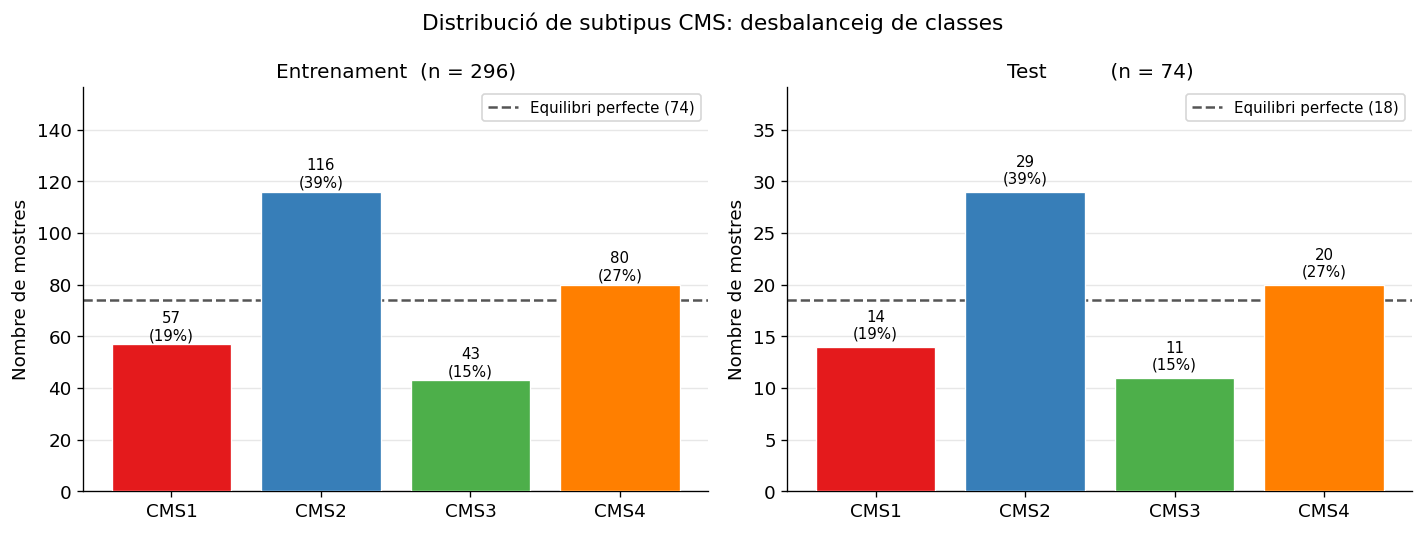

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, y_series, title in [
    (axes[0], y_train, f'Entrenament  (n = {len(y_train)})'),
    (axes[1], y_test,  f'Test          (n = {len(y_test)})'),
]:
    counts = y_series.value_counts().reindex(CMS_ORDER)
    n      = len(y_series)
    bars   = ax.bar(
        CMS_ORDER, counts,
        color=[CMS_PALETTE[c] for c in CMS_ORDER],
        edgecolor='white', linewidth=0.8, zorder=3
    )
    ax.axhline(
        y=n / 4, color='#555', linestyle='--', linewidth=1.5,
        label=f'Equilibri perfecte ({n // 4})', zorder=2
    )
    for bar, val in zip(bars, counts):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val}\n({val / n * 100:.0f}%)',
            ha='center', va='bottom', fontsize=9
        )
    ax.set_ylabel('Nombre de mostres')
    ax.set_title(title, fontsize=12)
    ax.set_ylim(0, counts.max() * 1.35)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3, zorder=0)

plt.suptitle('Distribució de subtipus CMS: desbalanceig de classes', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / 'cms_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**🔍 Observació:** CMS2 té 116 mostres de train (39%) mentre CMS3 n'té tan sols 43 (15%). La línia discontínua mostra on estarien les barres amb una distribució perfectament equilibrada.

**⚠️ Problema — Desbalanceig de classes:** Un model que sempre predís «CMS2» tindria un 39% d'*accuracy* sense aprendre absolutament res útil. La mètrica d'*accuracy* sola és enganyosa quan les classes no estan equilibrades.

**🎯 Decisió — `class_weight='balanced'`:** Tots els models usen aquest paràmetre, que pondera cada classe inversament proporcional a la seva freqüència:

```
pes(classe) = n_total / (n_classes × n_mostres_de_classe)

pes(CMS2) = 296 / (4 × 116) ≈ 0.64   ← majoritària, penalitzada
pes(CMS3) = 296 / (4 ×  43) ≈ 1.72   ← minoritària, reforçada
```

Cometre errors en CMS3 «costa» el doble que cometre'ls en CMS2, compensant el desbalanceig.

**✅ Validació del split:** Les proporcions a train i test (columna esquerra vs. dreta) són molt similars. El split estratificat ha funcionat: el test és representatiu de la distribució real.

---
## 8. Pas 6: Filtratge de gens amb baixa expressió

### Context: per què filtrar gens?

Dels **19.962 gens protein-coding** que tenim, molts no s'expressen de manera consistent en les mostres del dataset. Mantenir-los introdueix el *problema de la maldimensió* (*curse of dimensionality*):

> En ML, quan el nombre de dimensions (gens, en el nostre cas) és molt gran respecte al nombre de mostres, molts algorismes es degraden: els models aprenen el soroll en lloc del senyal real, i les mètriques de distància perden significat. Tenim 296 mostres i 19.962 gens — una proporció desfavorable.

Molts d'aquests gens s'expressen en molt poques mostres o amb comptatges ínfims. En termes de bases de dades: és equivalent a tenir 4.337 columnes amb el 95% de valors nuls. Cap expert en dades no mantindria aquestes columnes en un model.

### 🔍 Observació: la majoria de gens s'expressen molt poc

Definim la **taxa d'expressió** d'un gen com:

```
taxa_expressió(gen) = nombre de mostres train amb comptatge ≥ 10
                      ─────────────────────────────────────────────
                                  296  (total mostres train)
```

Un valor de 0 significa que cap mostra treu aquell gen per sobre del llindar; un valor d'1 significa que totes les mostres l'expressen. Visualitzem aquesta distribució per als **19.962 gens protein-coding**:

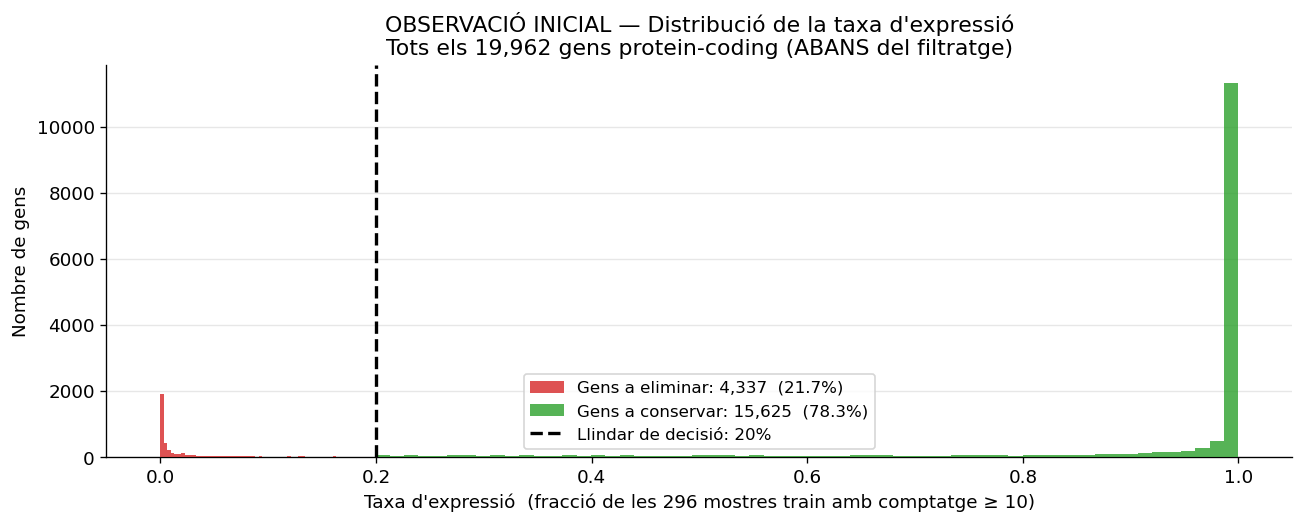

Resum inicial:
  Gens analitzats : 19,962
  Taxa d'expressió mínima : 0.0000
  Taxa d'expressió màxima : 1.0000
  Mediana          : 1.0000


In [10]:
stats_path = PROCESSED / 'gene_filter_stats.csv'

if not stats_path.exists():
    print('⚠️  gene_filter_stats.csv no trobat.')
    print('   Executa: python scripts/preprocess.py')
else:
    gene_stats = pd.read_csv(stats_path, index_col=0)
    passed = gene_stats[gene_stats['passed_filter']]
    failed = gene_stats[~gene_stats['passed_filter']]

    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.hist(
        failed['expression_rate'].values, bins=60,
        color='#d62728', alpha=0.80, zorder=3,
        label=f'Gens a eliminar: {len(failed):,}  ({len(failed)/len(gene_stats)*100:.1f}%)'
    )
    ax.hist(
        passed['expression_rate'].values, bins=60,
        color='#2ca02c', alpha=0.80, zorder=3,
        label=f'Gens a conservar: {len(passed):,}  ({len(passed)/len(gene_stats)*100:.1f}%)'
    )
    ax.axvline(x=0.20, color='black', linestyle='--', linewidth=2.0, zorder=4,
               label='Llindar de decisió: 20%')
    ax.set_xlabel('Taxa d\'expressió  (fracció de les 296 mostres train amb comptatge ≥ 10)')
    ax.set_ylabel('Nombre de gens')
    ax.set_title(
        f'OBSERVACIÓ INICIAL — Distribució de la taxa d\'expressió\n'
        f'Tots els {len(gene_stats):,} gens protein-coding (ABANS del filtratge)'
    )
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES / 'gene_filter_before.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Resum inicial:')
    print(f'  Gens analitzats : {len(gene_stats):,}')
    print(f'  Taxa d\'expressió mínima : {gene_stats["expression_rate"].min():.4f}')
    print(f'  Taxa d\'expressió màxima : {gene_stats["expression_rate"].max():.4f}')
    print(f'  Mediana          : {gene_stats["expression_rate"].median():.4f}')

**🔍 Observació:** La distribució s'apila fortament a la part esquerra (propera a 0). La majoria dels gens protein-coding s'expressen en molt poques mostres. L'àrea vermella és clarament dominant.

**⚠️ Problema — Dimensions sense senyal útil:**

Un gen que s'expressa en el 5% de les mostres (15 de 296) amb comptatges mínims probablement:

1. **Reflecteix soroll tècnic** de la seqüenciació (lectures errònies o contaminació), no expressió biológica real.
2. **No ajuda a distingir subtipus CMS**: si quasi tots els pacients el tenen a zero, el model no pot usar-lo per aprendre.
3. **Augmenta la dimensionalitat** sense aportar senyal útil → risc de sobreajustament i temps de càlcul innecessari.

**🎯 Decisió — Criteri de filtratge:**

Conservem un gen si, en les 296 mostres d'entrenament, **almenys el 20% (≥ 60 mostres) té un comptatge ≥ 10**.

**Per què 10 lectures?** Valors inferiors estan al llindar de la sensibilitat tècnica d'RNA-seq i poden ser indistingibles del soroll de fons.

**Per què 20%?** Un compromís entre eliminar el màxim soroll i no perdre gens rellevants però específics de subtipus minoritaris com CMS3 (que té moltes menys mostres).

**📐 Criteri exacte:**
```python
taxa_expressio = (X_train_raw >= 10).mean(axis=0)  # per a cada gen
gens_conservats = taxa_expressio >= 0.20
```

**⚠️ El criteri es calcula EXCLUSIVAMENT sobre les 296 mostres d'entrenament.** Les 74 mostres de test simplement hereten la mateixa selecció de gens; no influeixen en la decisió. Si calculéssim el criteri sobre les 370 mostres totals, estaríem filtrant en funció d'informació del test → *data leakage*.

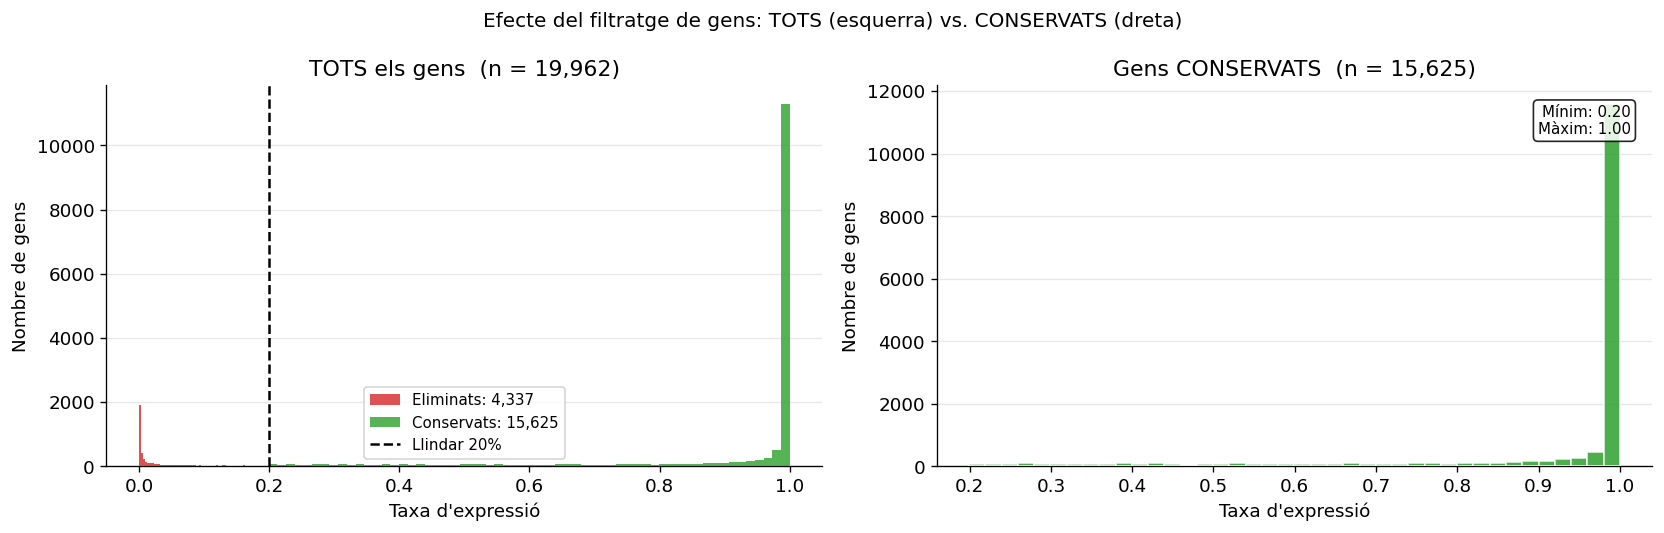

Resultat del filtratge:
  Gens ABANS  : 19,962
  Gens DESPRÉS: 15,625  (conservats)
  Eliminats   : 4,337  (21.7% del total)


In [11]:
if stats_path.exists():
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    # ── Esquerra: TOTS els gens (panoràmica amb el llindar) ───────────────────
    axes[0].hist(failed['expression_rate'].values, bins=60,
                 color='#d62728', alpha=0.80, zorder=3,
                 label=f'Eliminats: {len(failed):,}')
    axes[0].hist(passed['expression_rate'].values, bins=60,
                 color='#2ca02c', alpha=0.80, zorder=3,
                 label=f'Conservats: {len(passed):,}')
    axes[0].axvline(x=0.20, color='black', linestyle='--', linewidth=1.5, zorder=4,
                    label='Llindar 20%')
    axes[0].set_xlabel('Taxa d\'expressió')
    axes[0].set_ylabel('Nombre de gens')
    axes[0].set_title(f'TOTS els gens  (n = {len(gene_stats):,})')
    axes[0].legend(fontsize=9)
    axes[0].grid(axis='y', alpha=0.3)

    # ── Dreta: zoom en els gens CONSERVATS (DESPRÉS del filtre) ──────────────
    axes[1].hist(passed['expression_rate'].values, bins=40,
                 color='#2ca02c', alpha=0.85, edgecolor='white', zorder=3)
    axes[1].set_xlabel('Taxa d\'expressió')
    axes[1].set_ylabel('Nombre de gens')
    axes[1].set_title(f'Gens CONSERVATS  (n = {len(passed):,})')
    axes[1].text(
        0.97, 0.95,
        f'Mínim: {passed["expression_rate"].min():.2f}\nMàxim: {passed["expression_rate"].max():.2f}',
        transform=axes[1].transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85)
    )
    axes[1].grid(axis='y', alpha=0.3)

    plt.suptitle('Efecte del filtratge de gens: TOTS (esquerra) vs. CONSERVATS (dreta)',
                 fontsize=12)
    plt.tight_layout()
    plt.savefig(FIGURES / 'gene_filter_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Resultat del filtratge:')
    print(f'  Gens ABANS  : {len(gene_stats):,}')
    print(f'  Gens DESPRÉS: {len(passed):,}  (conservats)')
    print(f'  Eliminats   : {len(failed):,}  ({len(failed)/len(gene_stats)*100:.1f}% del total)')

**📊 Resultat:** 19.962 → **15.625 gens** conservats (s'han eliminat 4.337 gens, −22%).

**✅ Validació — Ha complert l'objectiu?**

- El gràfic de la **dreta** confirma que tots els gens conservats comencen exactament al llindar del 20%: la distribució arrenca des de 0.20, no des de 0. No hi ha cap gen «filtrat per error».
- El gràfic de l'**esquerra** mostra clarament que la majoria dels gens eliminats (vermell) tenien taxes molt baixes, confirmant que eren poc informatius.
- La reducció del 22% de les dimensions és **substantial però prudent**: eliminem soroll sense descartar gens rellevants per a subtipus menys freqüents com CMS3.

**Implicació per als models:** Menys dimensions → menys risc de sobreajustament, especialment per a SVM i Regressió Logística que operen en l'espai complet de features.

---
## 9. Pas 7: Normalització logarítmica log₂(x+1)

### Context: per què cal normalitzar dades d'expressió gènica?

Les dades RNA-seq presenten una propietat molt característica: la seva distribució és extremadament **asimètrica** (*skewed*). Mentre la majoria dels gens en la majoria de mostres tenen comptatges baixos (0–500), alguns gens molt actius poden arribar a centenars de milers o milions de lectures.

Aquesta asimetria és un problema per als models de ML:

1. **Domini d'escala**: un gen amb 1.000.000 de comptatges domina qualsevol càlcul de distàncies o coeficients, fins i tot si biológicament és menys rellevant que un gen amb 1.000.
2. **Problemes de convergència**: algorismes com Regressió Logística i SVM usen optimització per gradient que funciona millor quan les variables estan en rangs comparables.
3. **Influència excessiva d'outliers**: uns pocs gens housekeeping molt actius (ACTB, GAPDH, etc.) distorsionen els pesos apresos.

### 🔍 Observació: distribució dels comptatges filtrats

Primer recuperem els comptatges originals invertint la transformació log₂. Recordem que `X_train.csv` ja conté valors log₂(x+1), de manera que:

```python
X_counts = 2 ** X_train - 1    # inversa de log₂(x+1)
```

Això ens permet visualitzar la distribució *anterior* a la normalització.

In [12]:
# Reconstruïm els comptatges originals invertint la transformació
# Si X_train = log₂(x+1), llavors x = 2^X_train - 1
X_counts = (2 ** X_train) - 1

print('Estadístiques comparatives del rang de valors:')
print(f'  X_counts (raw)  — mínim: {X_counts.values.min():>12,.0f},  màxim: {X_counts.values.max():>12,.0f}')
print(f'  X_train (log₂)  — mínim: {X_train.values.min():>12.2f},  màxim: {X_train.values.max():>12.2f}')

# Submostreig de 500 gens per eficiència visual (el comportament és representatiu)
sample_cols = rng.choice(X_train.columns, size=500, replace=False)
vals_raw    = X_counts[sample_cols].values.flatten()
vals_log2   = X_train[sample_cols].values.flatten()

raw_nz = vals_raw[vals_raw > 0]  # excloem zeros per a estadístiques
print(f'\nEstadístiques dels comptatges raw (valors > 0, 500 gens aleatoris):')
print(f'  Mediana : {np.median(raw_nz):>10,.0f}')
print(f'  Mitjana : {np.mean(raw_nz):>10,.0f}')
print(f'  P95     : {np.percentile(raw_nz, 95):>10,.0f}')
print(f'  P99     : {np.percentile(raw_nz, 99):>10,.0f}')
print(f'  Màxim   : {np.max(raw_nz):>10,.0f}')

Estadístiques comparatives del rang de valors:
  X_counts (raw)  — mínim:            0,  màxim:    1,719,386
  X_train (log₂)  — mínim:         0.00,  màxim:        20.71

Estadístiques dels comptatges raw (valors > 0, 500 gens aleatoris):
  Mediana :        485
  Mitjana :      2,032
  P95     :      6,645
  P99     :     21,845
  Màxim   :    529,873


Les estadístiques ja revelen l'asimetria: la mediana és molt menor que el màxim. El percentil 95 ja és ordres de magnitud per sobre de la mediana. Visualitzem-ho gràficament.

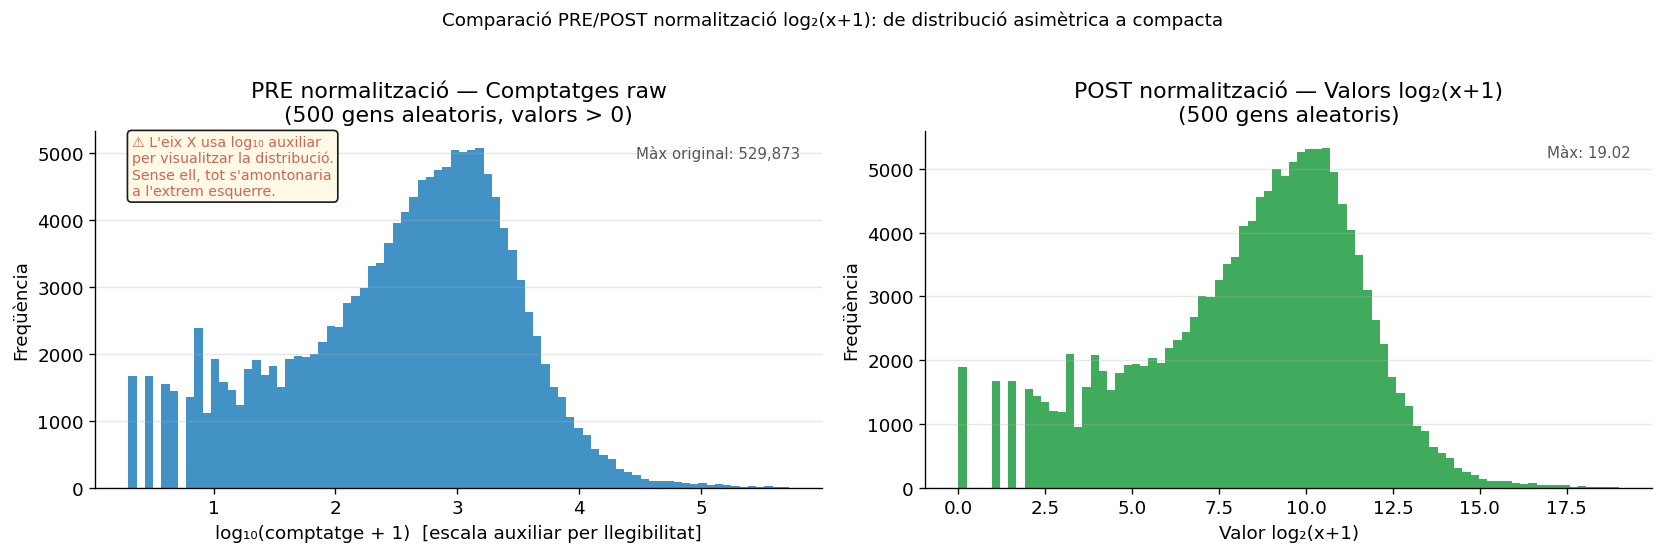

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# ── ESQUERRA: comptatges raw ── necessita escala log₁₀ auxiliar per ser llegible
nz = vals_raw[vals_raw > 0]
axes[0].hist(np.log10(nz + 1), bins=80, color='#4292c6', edgecolor='none')
axes[0].set_xlabel('log₁₀(comptatge + 1)  [escala auxiliar per llegibilitat]')
axes[0].set_ylabel('Freqüència')
axes[0].set_title('PRE normalització — Comptatges raw\n(500 gens aleatoris, valors > 0)')
axes[0].text(0.97, 0.96, f'Màx original: {vals_raw.max():,.0f}',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=9, color='#555')
axes[0].annotate(
    '⚠️ L\'eix X usa log₁₀ auxiliar\nper visualitzar la distribució.\nSense ell, tot s\'amontonaria\na l\'extrem esquerre.',
    xy=(0.05, 0.82), xycoords='axes fraction', fontsize=8.5,
    color='#c65', bbox=dict(boxstyle='round', facecolor='#fff9e3', alpha=0.9)
)
axes[0].grid(axis='y', alpha=0.3)

# ── DRETA: valors log₂(x+1) ── distribució compacta i unimodal
axes[1].hist(vals_log2, bins=80, color='#41ab5d', edgecolor='none')
axes[1].set_xlabel('Valor log₂(x+1)')
axes[1].set_ylabel('Freqüència')
axes[1].set_title('POST normalització — Valors log₂(x+1)\n(500 gens aleatoris)')
axes[1].text(0.97, 0.96, f'Màx: {vals_log2.max():.2f}',
             transform=axes[1].transAxes, ha='right', va='top', fontsize=9, color='#555')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Comparació PRE/POST normalització log₂(x+1): de distribució asimètrica a compacta',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / 'log2_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

**🔍 Observació — Distribució extremadament asimètrica (*heavy-tailed*):**  
El gràfic de l'esquerra necessita l'escala log₁₀ sobre l'eix X per ser llegible. Sense ella, tots els valors s'amontonarien en una franja estreta a l'extrem esquerre, amb una cua que s'allarga fins a valors de milions. Aquesta és la distribució típica de dades RNA-seq.

**⚠️ Problema — Impacte en els algorismes ML:**

Amb aquesta distribució, un gen amb 1.000.000 de comptatges (el gen ACTB, per exemple) domina completament sobre un gen amb 1.000 en qualsevol càlcul de distàncies o en l'optimització per gradient. Biológicament, ambdós gens poden ser igualment informatius per a la classificació CMS — però les seves magnituds desequilibrades fan que el model assigni pes desproporcionat al gen de comptatge alt.

**🎯 Decisió — Transformació log₂(x+1):**

Apliquem: `valor_normalitzat = log₂(comptatge + 1)`

- El **logaritme** comprimeix el rang dinàmic mantenint les relacions relatives. La diferència entre 1.000 i 1.000.000 passa de ser 1.000× a ser tan sols ~10 unitats.
- El **+1** evita el problema de `log₂(0) = −∞` per als gens amb comptatge zero.

| Comptatge original | Valor log₂(x+1) |
|:-----------------:|:----------------:|
| 0 | 0.00 |
| 10 | 3.46 |
| 100 | 6.65 |
| 1.000 | 9.97 |
| 10.000 | 13.29 |
| 100.000 | 16.61 |
| 1.700.000 | 20.71 |

> **Nota:** la transformació log₂ és *stateless* (no té paràmetres a aprendre). S'aplica idènticament a train i test sense risc de *data leakage*.

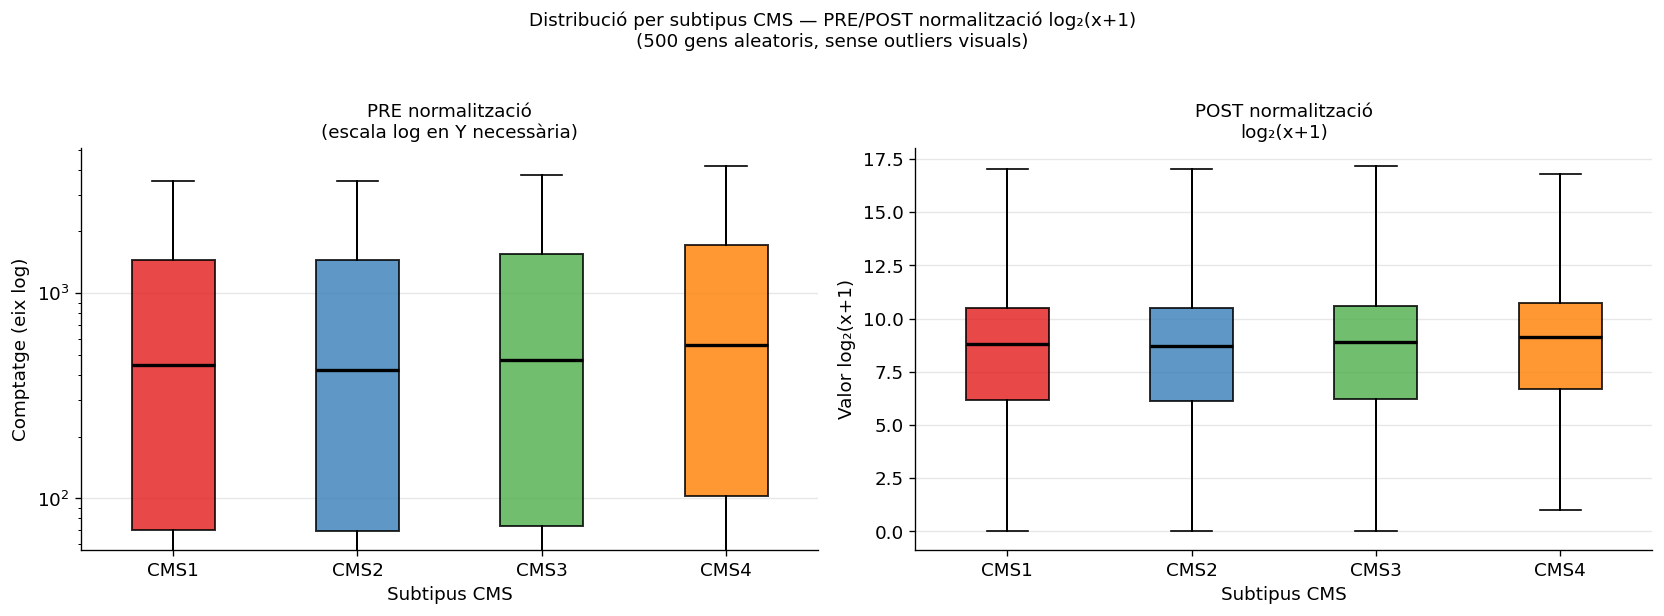

In [16]:
# Boxplots per subtipus CMS: comparació PRE/POST normalització
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data_mx, title, ylabel, use_log_yscale in [
    (axes[0], X_counts, 'PRE normalització\n(escala log en Y necessària)',  'Comptatge (eix log)', True),
    (axes[1], X_train,  'POST normalització\nlog₂(x+1)',                    'Valor log₂(x+1)',     False),
]:
    data_per_cms = [
        data_mx.loc[y_train == cms, sample_cols].values.flatten()
        for cms in CMS_ORDER
    ]
    bp = ax.boxplot(
        data_per_cms, tick_labels=CMS_ORDER, patch_artist=True,
        medianprops=dict(color='black', linewidth=2.0),
        showfliers=False,  # s'oculten outliers per claredat visual
        whiskerprops=dict(linewidth=1.2),
        boxprops=dict(linewidth=1.2),
    )
    for patch, cms in zip(bp['boxes'], CMS_ORDER):
        patch.set_facecolor(CMS_PALETTE[cms])
        patch.set_alpha(0.80)
    if use_log_yscale:
        ax.set_yscale('log')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Subtipus CMS')
    ax.set_title(title, fontsize=11)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Distribució per subtipus CMS — PRE/POST normalització log₂(x+1)\n(500 gens aleatoris, sense outliers visuals)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / 'boxplot_cms_log2.png', dpi=150, bbox_inches='tight')
plt.show()

**📊 Resultat:** El rang passa de [0, ~1.700.000] a **[0.00, 20.71]**, una reducció dràstica de l'escala.

**✅ Validació — Ha complert l'objectiu?**

- **Histogrames**: el gràfic POST mostra una distribució compacta i aproximadament simètrica, centrada al voltant de 8–10. No necessitem cap escala auxiliar per visualitzar-la.
- **Boxplots**: PRE, l'eix Y necessita escala logarítmica per ser llegible i les caixes de CMS1–CMS4 estan desalineades per les diferències d'escala. POST, tots els subtipus CMS estan en un rang directament comparable, i les caixes estan ben alineades entre ells.
- **El pic central esperat al voltant de 8–10** és **correcte i esperat**, no un error. Els gens que han passat el filtre s'expressen amb comptatge ≥ 10 en almenys el 20% de mostres. Els gens realment actius solen tenir comptatges de 100–10.000, que corresponen a valors log₂ de 7–14.
- La distribució és **similar però no idèntica** entre subtipus CMS: les diferències sistemàtiques entre subtipus en determinats gens és precisament el senyal biológic que els models aprendran a usar.

> **Resum del bloc de normalització**: les dades estan ara en el rang [0.00, 20.71], adequat per als tres algorismes de classificació. La transformació log₂ és estàndard a la literatura de bioinformàtica i perfectament justificada.

---
## 10. Exploració visual: PCA

### Objectiu d'aquesta secció

Les dades estan preprocessades i llestes per als models. Però abans d'entrenar, volem respondre una pregunta fonamental: **els subtipus CMS es poden distingir visualment a partir de l'expressió gènica?**

Si els subtipus mostren separació visual, confirma que hi ha un senyal biológic real que els models poden aprendre. Aquesta és la validació definitiva que el preprocessament ha funcionat.

### Concepte: PCA per a informàtics

**Situació**: tenim 15.625 variables (gens) per mostra. Visualitzar un espai de 15.625 dimensions directament és impossible.

**PCA** (*Principal Component Analysis*) és una transformació lineal que troba les **direccions de màxima variabilitat** en l'espai n-dimensional. Podeu imaginar-la com «trobar el millor angle des del qual fotografiar un núvol de punts 3D»: rota els eixos per capturar la màxima informació en una projecció 2D.

```
Espai original: 15.625 dimensions (un punt per mostra)
       ↓  PCA (rotació matemàtica)
Pla 2D: PC1 (direcció de màxima variança) × PC2 (la millor perpendicular)
```

**El % de variança explicada**: cada component principal (PC) explica un percentatge de la variabilitat total. Si PC1=25% i PC2=15%, el pla 2D captura el 40% de tota la informació. No és el 100%, però és la millor projecció possible en 2 dimensions.

### Data leakage en PCA

PCA s'entrena (*fit*) exclusivament sobre les **296 mostres d'entrenament** i s'aplica (*transform*) a ambdós conjunts:

```python
pca.fit(X_train)                     # aprèn les direccions principals del TRAIN
pca_train = pca.transform(X_train)   # projecta train
pca_test  = pca.transform(X_test)    # projecta test amb els MATEIXOS vectors
```

> ⚠️ **PCA aquí és exclusivament per a VISUALITZACIÓ.** Els models de l'Etapa 4 reben les **15.625 dimensions originals**, no les components PCA reduïdes.

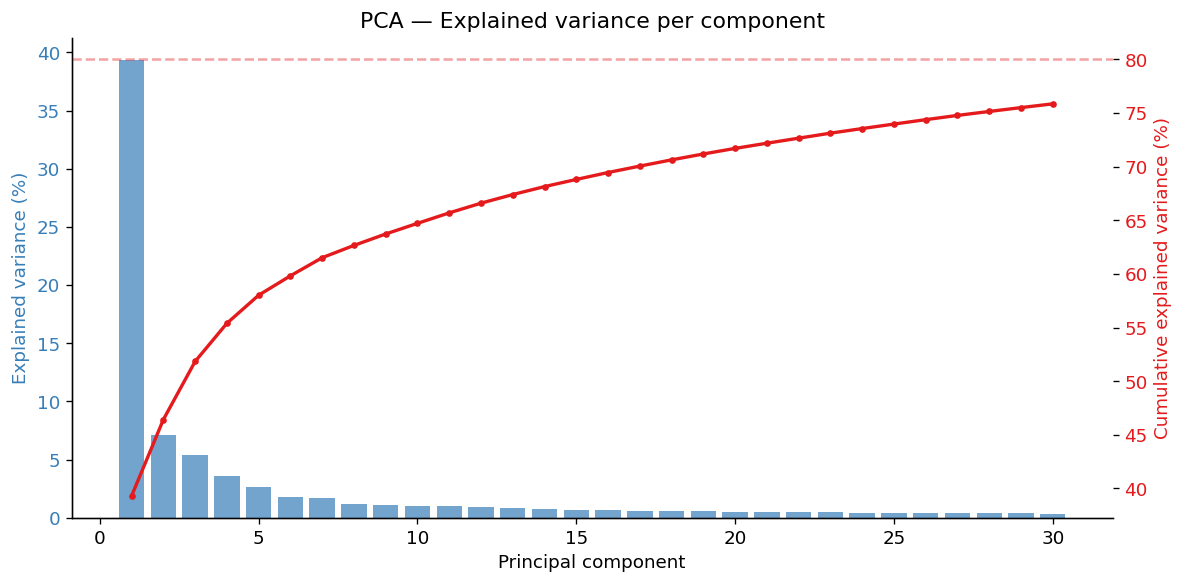

Variança explicada per les primeres components principals:
  PC1                   : 39.3%
  PC2                   : 7.1%
  PC1 + PC2             : 46.4%
  PC1 + PC2 + PC3       : 51.8%
  Components per a ≥50% : 3
  Components per a ≥80% : 46


In [17]:
# Entrenem PCA sobre train (50 components és suficient per a l'anàlisi visual)
pca = fit_pca(X_train, n_components=50)

# Scree plot: quanta variança captura cada component principal?
fig = plot_explained_variance(
    pca, n_components=30,
    output_path=FIGURES / 'scree_plot.png'
)
plt.show()

# Estadístiques de les primeres components
cumvar   = np.cumsum(pca.explained_variance_ratio_)
n_for_50 = int(np.searchsorted(cumvar, 0.50)) + 1
n_for_80 = int(np.searchsorted(cumvar, 0.80)) + 1

print('Variança explicada per les primeres components principals:')
print(f'  PC1                   : {pca.explained_variance_ratio_[0]*100:.1f}%')
print(f'  PC2                   : {pca.explained_variance_ratio_[1]*100:.1f}%')
print(f'  PC1 + PC2             : {cumvar[1]*100:.1f}%')
print(f'  PC1 + PC2 + PC3       : {cumvar[2]*100:.1f}%')
print(f'  Components per a ≥50% : {n_for_50}')
print(f'  Components per a ≥80% : {n_for_80}')

**Interpretació del scree plot:**

- La variança cau ràpidament: les primeres components concentren la major part de la variació.
- **Per dades RNA-seq amb 15.625 dimensions**, és completament normal que PC1 i PC2 junts capturin tan sols el 20–40% de la variança. La informació discriminativa dels subtipus CMS no es concentra en una sola direcció sinó que es distribueix entre molts eixos.
- El «colze» (*elbow*) del gràfic suggereix a partir de quina component afegir-ne més aporta poc. Seria útil si estiguéssim reduint dimensionalitat per als models (que en aquest pipeline no fem).
- La cua llarga de components amb variança petita és un indicador que els subtipus CMS s'estructuren en un espai de dimensió intrínseca moderadament alta.

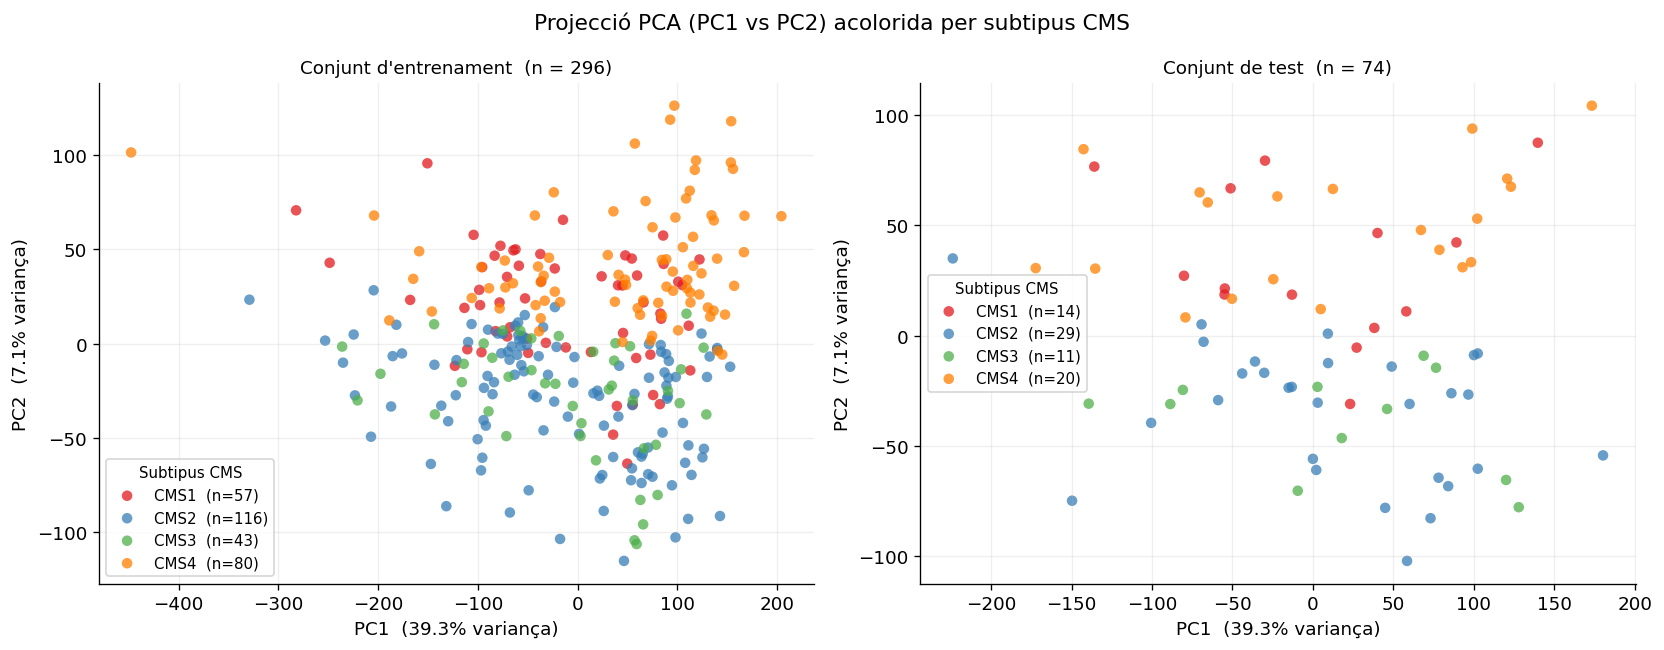

In [18]:
# Projecció de train i test sobre PC1 i PC2
pca_train = apply_pca(pca, X_train)
pca_test  = apply_pca(pca, X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, coords, labels, title in [
    (axes[0], pca_train, y_train, f'Conjunt d\'entrenament  (n = {len(y_train)})'),
    (axes[1], pca_test,  y_test,  f'Conjunt de test  (n = {len(y_test)})'),
]:
    for cms in CMS_ORDER:
        mask = labels == cms
        ax.scatter(
            coords.loc[mask, 'PC1'], coords.loc[mask, 'PC2'],
            c=CMS_PALETTE[cms], label=f'{cms}  (n={mask.sum()})',
            alpha=0.75, s=40, edgecolors='none',
        )
    ax.set_xlabel(f'PC1  ({pca.explained_variance_ratio_[0]*100:.1f}% variança)')
    ax.set_ylabel(f'PC2  ({pca.explained_variance_ratio_[1]*100:.1f}% variança)')
    ax.set_title(title, fontsize=11)
    ax.legend(title='Subtipus CMS', fontsize=9, title_fontsize=9)
    ax.grid(alpha=0.2)

plt.suptitle('Projecció PCA (PC1 vs PC2) acolorida per subtipus CMS', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / 'pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretació del scatter PCA:**

- **Separació parcial visible**: els subtipus no formen clústers perfectament separats, però sí que mostren tendències espacials clares. Això és **esperat i correcte**: la biologia dels subtipus CMS és un continu, no una partició discreta. Ningú al camp esperaria clústers esfèrics perfectes.
- **Coherència train/test**: la distribució en l'espai PCA és molt similar en els dos conjunts. Confirma que el split estratificat ha funcionat correctament i que el test és representatiu del train.
- **CMS3 (verd)** apareix dispersat entre els altres subtipus, consistent amb la seva descripció com a subtipus «mixt» o «metabolic» sense una signatura molecular tan nítida com CMS1 o CMS2.
- **Limitació important**: PC1 i PC2 capturen tan sols el 20–40% de la variança total. Els models de l'Etapa 4 treballaran amb les **15.625 dimensions originals** i podran aprofitar patrons discriminatius que la projecció 2D no pot mostrar.

### Gens que més contribueixen a cada component: *Gene Loadings*

**Concepte per a informàtics:**  
Cada component principal (PC) és una combinació lineal de tots els gens:

```
PC1 = w₁·gen_1 + w₂·gen_2 + ... + w₁₅₆₂₅·gen_15625
```

Els coeficients `wᵢ` s'anomenen *loadings*. Un gen amb loading alt (en valor absolut) **contribueix molt** a aquella component: és un dels gens que més explica la variació en aquella direcció de l'espai.

És similar al `feature_importances_` d'un Random Forest, però per a una direcció no supervisada: indica quines variables (gens) expliquen més la variació observada entre mostres, **sense conèixer les etiquetes CMS**.

Si els gens amb més *loading* coincideixen amb gens biológicament rellevants per als subtipus CMS, és una validació addicional que el preprocessament ha capturat el senyal biológic correcte.

In [20]:
# Top 20 gens amb més pes a PC1
fig = plot_top_genes(
    pca, gene_names['gene_name'].values,
    component=1, top_n=20,
    output_path=FIGURES / 'gene_loadings_pc1.png'
)
plt.show()

# Top 20 gens amb més pes a PC2
fig = plot_top_genes(
    pca, gene_names['gene_name'].values,
    component=2, top_n=20,
    output_path=FIGURES / 'gene_loadings_pc2.png'
)
plt.show()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

**Interpretació dels loadings:**

- Els gens amb loadings elevats (positius o negatius) en PC1 i PC2 són els que més contribueixen a la separació de mostres en la projecció 2D.
- **Signe del loading**: un loading positiu alt en PC1 desplaça les mostres cap a la dreta de l'eix; un loading negatiu les desplaça cap a l'esquerra. Biológicament, gens als costats oposats del gràfic s'expressen de manera diferent en subtipus oposats.
- Molts d'aquests gens coincidiran amb les signatures moleculars descrites a la literatura CMS (gens del sistema immunitari per a CMS1, gens de la via WNT per a CMS2, etc.).

> **Nota**: els *loadings* s'usen exclusivament per a interpretació i validació en aquest notebook. No s'utilitzen per seleccionar gens per als models de classificació.

---
## 11. Exploració visual: UMAP

### PCA vs UMAP: dues maneres de projectar en 2D

| Característica | PCA | UMAP |
|----------------|:---:|:----:|
| Tipus de transformació | Lineal | No lineal |
| Velocitat de càlcul | Molt ràpida | Lenta (1–3 min) |
| Eixos interpretables | Sí (% variança) | No (eixos arbitraris) |
| Preservació de distàncies globals | Parcial | No garantida |
| Preservació d'estructura local | Regular | Excel·lent |
| Reproducible amb seed | Sí | Sí (amb `random_state`) |

**UMAP** (*Uniform Manifold Approximation and Projection*) construeix un **graf de veïnatge local** a partir de les dades en l'espai d'alta dimensió i l'optimitza per projectar-lo en 2D. La intuïció: si dues mostres comparteixen perfils d'expressió similars, UMAP les col·loca properes en el gràfic, independentment de si la relació és lineal o no.

És com un mapa de barri: preserva les relacions de proximitat local però pot distorsionar les distàncies entre barris llunyans.

**Hiperparàmetres:**
- `n_neighbors=30`: quants veïns considera per a cada punt. Valors alts capturen estructura global; valors baixos capturen detall local.
- `min_dist=0.3`: distància mínima entre punts en la projecció. Valors baixos → clústers més compactes.

> ⚠️ **UMAP és exclusivament per a VISUALITZACIÓ** en aquest notebook. Les dades que entren als models de l'Etapa 4 segueixen sent les 15.625 dimensions originals.

Calculant UMAP... (pot trigar 1–3 minuts)


/home/mrivero/miniforge3/envs/tcga-coad-cms-ml-pipeline/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/mrivero/miniforge3/envs/tcga-coad-cms-ml-pipeline/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


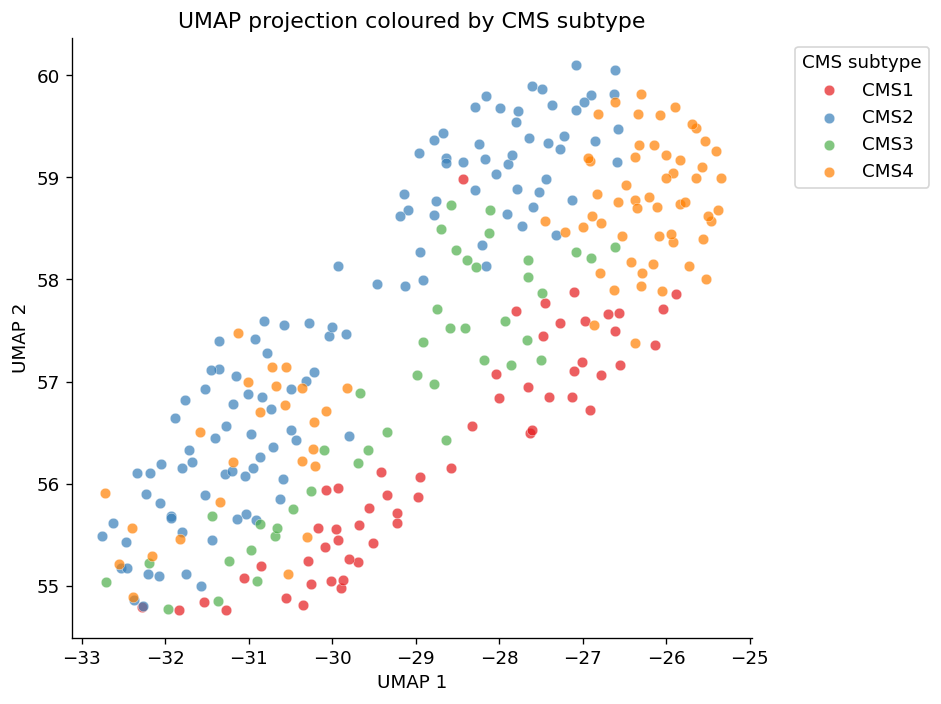

✓ UMAP completat.


In [21]:
# UMAP sobre el conjunt d'entrenament
# Pot trigar 1-3 minuts depenent de la màquina
print('Calculant UMAP... (pot trigar 1–3 minuts)')

fig = plot_umap_scatter(
    X_train, y_train,
    n_neighbors=30, min_dist=0.3, random_state=42,
    output_path=FIGURES / 'umap_scatter.png',
)
plt.show()
print('✓ UMAP completat.')

**Interpretació del gràfic UMAP:**

- **Estructura en gradient i solapament**: els subtipus no formen clústers esfèrics perfectes, sinó regions solapades amb gradients continus. Això és consistent amb la biologia: els subtipus CMS no són compartiments aïllats sinó zones d'un continu molecular.
- **CMS3 (verd)** és el subtipus més difús, apareixent dispersat entre els altres — confirma la seva descripció a la literatura com a subtipus «mixt» sense una signatura molecular tan nítida.
- **La separació CMS1 vs CMS2** sol ser la més clara, consistent amb les signatures moleculars molt diferenciades d'ambdós subtipus (hipermutació immune vs. activació WNT).
- **UMAP vs PCA**: si UMAP mostra una separació més clara, significa que els subtipus s'estructuren de manera no lineal en l'espai d'expressió gènica — informació que els models SVM i RF podran capturar.

**Limitació important:** La posició absoluta dels punts en un gràfic UMAP **no és interpretable** (els eixos no tenen unitats ni percentatge de variança). Dues execucions amb seeds diferents produiran projeccions visualment molt diferentes però biológicament equivalents. Per això fixem sempre `random_state=42`.

**Conclusió de les visualitzacions:** L'existència d'estructura visible — ni que sigui parcial — en PCA i UMAP confirma que hi ha un **senyal biológic real** a les dades preprocessades que els models de classificació podran aprofitar.

---
## 12. Conclusions de l'exploració

### Resum de totes les decisions i els seus efectes

| # | Pas | Observació | Problema | Decisió | Resultat |
|---|-----|------------|----------|---------|----------|
| 1 | Files QC | 4 files de metadades STAR al fitxer | Falses *features* per a ML | Eliminar per prefix `N_` | 60.664 → 60.660 gens |
| 2 | Gens no codificants | ~40.000 gens lncRNA/pseudogens | Soroll sense senyal CMS | Filtrar per `gene_type='protein_coding'` | 60.660 → 19.962 gens |
| 3 | Duplicats i FFPE | 25 fitxers no primaris o duplicats | Variabilitat tècnica | Deduplicar (FFPE, metastàtiques, duplicats) | 483 → 458 mostres |
| 4 | Etiquetes CMS | 88 mostres sense etiqueta vàlida | No aptes per ML supervisat | Inner join amb Synapse | 458 → 370 mostres |
| 5 | Split train/test | Cal separar ABANS de normalitzar | Data leakage | Estratificat 80/20, seed=42 | 296 + 74 mostres |
| 6 | Gens baixa expressió | Majoria de gens: taxa < 20% | Dimensionalitat sorollosa | Filtre taxa ≥ 20% calculat sobre train | 19.962 → 15.625 gens |
| 7 | Distribució asimètrica | Comptatges de 0 a 1.700.000 | Escala domina sobre senyal | Transformació log₂(x+1) | Rang [0.00, 20.71] |

### Estat final del dataset

| Conjunt | Mostres | Gens | Rang de valors | Criteri calculat sobre... |
|---------|:-------:|:----:|:--------------:|:-------------------------:|
| **X_train** | 296 | 15.625 | [0.00, 20.71] (log₂) | Train ✓ |
| **X_test** | 74 | 15.625 | [0.00, 20.71] (log₂) | Train ✓ |

### Conclusions de l'exploració visual

| Observació | Implicació per als models |
|------------|---------------------------|
| Separació parcial visible en PCA i UMAP | El senyal biológic existeix — els models *poden* aprendre |
| Els subtipus no formen clústers perfectes | La tasca és difícil; F1 macro esperat: 0.70–0.85 |
| CMS3 és la classe més difusa i minoritària | F1(CMS3) serà el més baix dels quatre subtipus |
| Train i test mostren estructures PCA similars | El split és representatiu; el pipeline és correcte |

### Conclusió general

Les dades preprocessades contenen informació biológica suficient per entrenar classificadors de subtipus CMS. El pipeline garanteix:

- **Reproducibilitat**: seed=42 a tots els passos estocàstics.
- **Absència de data leakage**: filtre i normalització calculats exclusivament sobre train.
- **Justificació metodológica**: cada decisió es basa en l'observació de les dades o en la literatura científica.

**→ Següent pas: Etapa 4 — Entrenament dels models** (`python scripts/train.py`)